<img src="../images/practicum_ai_logo.png" alt="Practicum AI Logo" align="right" width="250">

---

# 04: The State Space Architect
### Mamba, Selective State Spaces, and the Road to 131k Base Pairs

In Notebook 03, **Dr. Aris** showed how Transformers read DNA — powerfully, but with a fundamental constraint: the O(n²) attention matrix that makes long sequences computationally prohibitive. For 57 bp promoters, that constraint was invisible. For the genomic tasks that actually matter in the clinic — enhancer regulation, splicing across introns, chromatin loop anchors — it is a hard wall.

This notebook crosses that wall. We introduce **State Space Models (SSMs)** and their most important variant, **Mamba** — an architecture that replaces the attention matrix entirely with a compressed recurrent state that updates in O(n) time and O(1) memory. Then we fine-tune **Caduceus**, the leading Mamba-based DNA foundation model, which was pretrained on the human genome with a context window of **131,072 base pairs**.

---
### 🎯 Learning Objectives
1. **The quadratic bottleneck** — quantify exactly where and why Transformers fail at long sequences
2. **SSM mathematics** — derive the continuous-time equations and their discrete recurrence
3. **Mamba's innovation** — understand input-dependent selection and why it beats vanilla SSMs for DNA
4. **Bidirectionality** — see why DNA requires context from both directions and how Caduceus solves it
5. **Benchmark** — compare Caduceus directly against NB03's Transformer models on identical data

### 📚 Models We'll Cover
1. **Selective SSM (from scratch)** — implement the Mamba update step to make the math concrete
2. **Mamba DNA Classifier (from scratch)** — full SSM-based classifier; our architecture floor
3. **Caduceus (pretrained, 118M)** — bidirectional Mamba foundation model, 131k bp context

### 📐 Series Position

| NB | Architecture | Max context | Complexity |
|---|---|---|---|
| NB03 | Transformer | ~512 bp | O(n²) |
| **NB04** | **Mamba / SSM** | **131k bp** | **O(n)** |
| NB05 | Hyena | 1,000,000 bp | O(n log n) |

## 0. Environment Setup

All dependencies are pre-installed in the `biotm3` conda environment on HiPerGator. Caduceus uses `trust_remote_code=True` — the Mamba custom code downloads automatically from HuggingFace on first run.

> **Memory note:** Caduceus (118M) requires ~1 GB VRAM. Shut down the NB03 kernel before running if VRAM is tight.

In [1]:
# Core dependencies (always needed)
# !pip install torch transformers datasets pandas requests scikit-learn matplotlib seaborn

# Mamba CUDA kernels — required for real Mamba on GPU
# These require a compatible CUDA toolkit (≥11.6) and will NOT install on CPU-only machines
# !pip install mamba-ssm causal-conv1d

# Caduceus model (HuggingFace)
# !pip install caduceus

print("Uncomment the lines above if running for the first time.")
print("On HiPerGator: all packages should already be available in the BioAI environment.")

Uncomment the lines above if running for the first time.
On HiPerGator: all packages should already be available in the BioAI environment.


In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import math
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports successful")

✅ Imports successful


## 1. Hardware Detection

Mamba's production-grade CUDA kernels (used in real deployments) only run on GPU. Our simplified educational SSM implementation runs on any device, but the pretrained Caduceus model requires CUDA for efficient loading.

> **HiPerGator users:** You're running on an NVIDIA L4 GPU — optimal for this notebook.

In [3]:
def get_device():
    if torch.cuda.is_available():
        print("🚀 HiPerGator Detected: Utilizing CUDA")
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   CUDA Version: {torch.version.cuda}")
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        print("💻 Apple Silicon Detected: Utilizing MPS")
        print("   Note: Mamba CUDA kernels not available — using pure PyTorch SSM")
        return torch.device("mps")
    else:
        print("☁️ CPU Mode — simplified Mamba only")
        return torch.device("cpu")

device = get_device()
torch.manual_seed(42)
np.random.seed(42)
print(f"\n✅ Device ready: {device.type.upper()}")

🚀 HiPerGator Detected: Utilizing CUDA
   GPU: NVIDIA L4
   CUDA Version: 12.8

✅ Device ready: CUDA


## 2. The Transformer Bottleneck: Why O(n²) Matters in Genomics

*"Transformers compute attention between every pair of tokens. For a sequence of length n, that's n² pairs. For a 1 million base-pair gene locus, that's 1 trillion attention scores — per layer."* — Dr. Aris

### The Math
- **Attention complexity:** $O(n^2 \cdot d)$ — $n$ = sequence length, $d$ = hidden dimension
- **Memory to store the attention matrix:** $O(n^2)$
- **Key consequence:** doubling the sequence length **quadruples** memory

### Where Genomics Hits This Wall

| Genomic task | Typical sequence length | Transformer feasible? |
|---|---|---|
| Promoter detection (this series) | 57 bp | ✅ Trivial |
| Transcription factor binding sites | 200–500 bp | ✅ Fine |
| Splicing prediction | ~10,000 bp | ⚠️ Memory intensive |
| Enhancer–promoter interactions | ~100,000 bp | ❌ Memory explodes |
| TAD boundary modeling | ~1,000,000 bp | ❌ Impossible |

State Space Models replace the $O(n^2)$ attention matrix with a compressed hidden state updated one token at a time — breaking the wall entirely.

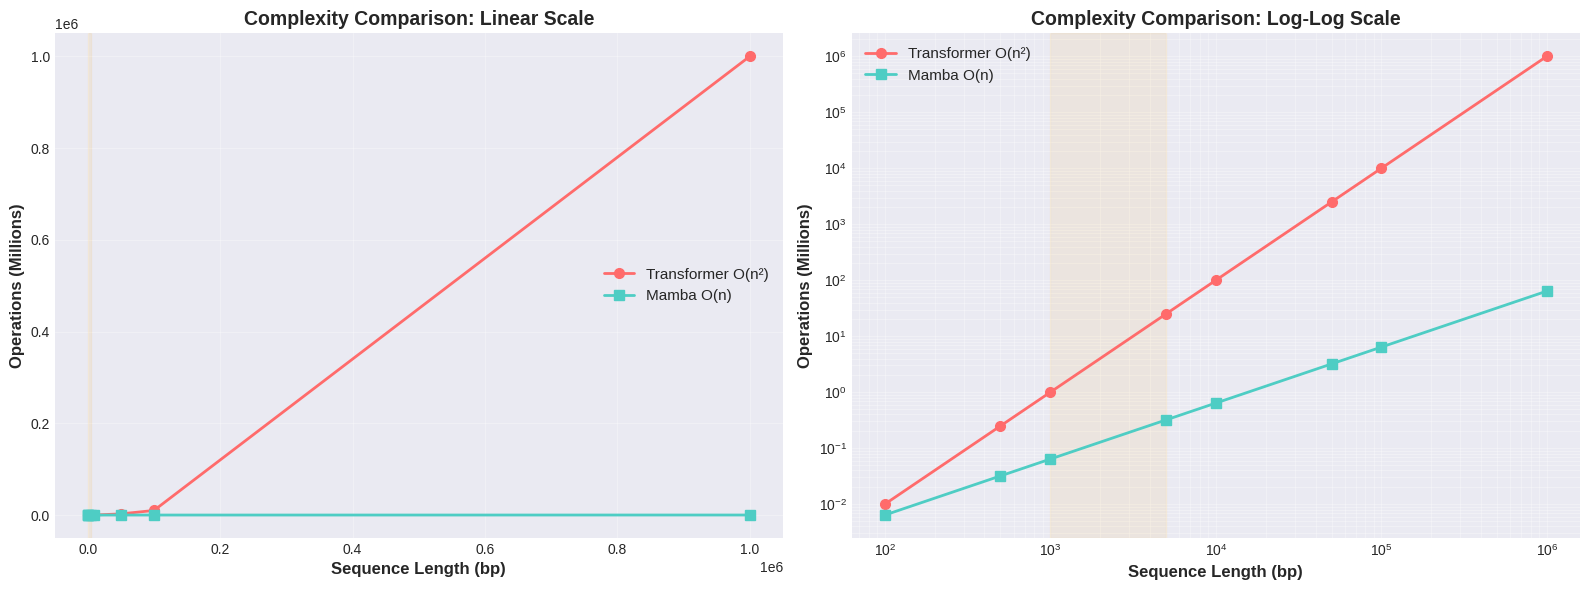

📊 Concrete numbers:
       10,000 bp → Transformer:        100M ops | Mamba:     0.64M ops | Mamba is 156x cheaper
       50,000 bp → Transformer:       2500M ops | Mamba:     3.20M ops | Mamba is 781x cheaper
    1,000,000 bp → Transformer:    1000000M ops | Mamba:    64.00M ops | Mamba is 15625x cheaper


In [4]:
sequence_lengths = np.array([100, 500, 1000, 5000, 10000, 50000, 100000, 1000000])

transformer_ops = sequence_lengths ** 2
mamba_ops       = sequence_lengths * 64   # O(n·d), d=64 state size

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, yscale, title in zip(axes, ['linear', 'log'], ['Linear Scale', 'Log-Log Scale']):
    ax.plot(sequence_lengths, transformer_ops / 1e6, 'o-', linewidth=2, markersize=7,
            color='#FF6B6B', label='Transformer O(n²)')
    ax.plot(sequence_lengths, mamba_ops / 1e6, 's-', linewidth=2, markersize=7,
            color='#4ECDC4', label='Mamba O(n)')
    ax.set_xlabel('Sequence Length (bp)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Operations (Millions)', fontsize=12, fontweight='bold')
    ax.set_title(f'Complexity Comparison: {title}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, which='both')
    if yscale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')

    # Annotate the crossover region
    ax.axvspan(1000, 5000, alpha=0.08, color='orange', label='Transformer starts struggling')

plt.tight_layout()
plt.show()

print("📊 Concrete numbers:")
for length, t_ops, m_ops in zip(sequence_lengths[[4,5,7]],
                                 transformer_ops[[4,5,7]],
                                 mamba_ops[[4,5,7]]):
    ratio = t_ops / m_ops
    print(f"   {length:>10,} bp → Transformer: {t_ops/1e6:>10.0f}M ops | "
          f"Mamba: {m_ops/1e6:>8.2f}M ops | Mamba is {ratio:.0f}x cheaper")

## 3. Load Promoter Dataset

Same UCI Promoter dataset and **identical 70/15/15 split** as Notebook 03. Every model in the series is evaluated on the same 16 test sequences — cross-notebook comparison is valid.

In [5]:
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data"

print("📥 Fetching UCI Promoter Dataset...")
response = requests.get(url)

lines = [line.strip().split(',') for line in response.text.strip().split('\n') if line.strip()]

processed_data = []
for line in lines:
    label    = 1 if line[0].strip() == '+' else 0
    sequence = line[2].replace('\t', '').replace(' ', '').upper()
    processed_data.append({"sequence": sequence, "label": label})

df = pd.DataFrame(processed_data)

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

BATCH_SIZE = 16 if device.type == "cuda" else 8

print(f"✅ Loaded {len(df)} sequences")
print(f"   Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"   Batch size: {BATCH_SIZE}")

📥 Fetching UCI Promoter Dataset...
✅ Loaded 106 sequences
   Train: 74, Val: 16, Test: 16
   Batch size: 16


## 4. State Space Models: The Theory

**Dr. Aris's Explanation:**
> *"Transformers ask: 'How does every token relate to every other token?' SSMs ask something different: 'What is the minimum amount of information I need to remember from the past to predict the future?'"*

### The Continuous SSM (from Control Theory)

A State Space Model describes a system with two equations:

$$h'(t) = \mathbf{A}\, h(t) + \mathbf{B}\, x(t) \qquad \text{(State update)}$$

$$y(t) = \mathbf{C}\, h(t) + \mathbf{D}\, x(t) \qquad \text{(Output)}$$

Where:
- $x(t)$: Input signal at time $t$ (a DNA nucleotide or token)
- $h(t)$: Hidden state — the model's "working memory"
- $y(t)$: Output at time $t$
- $\mathbf{A, B, C, D}$: Learnable matrices

### Discretization: From Continuous to Sequence Models

Since DNA is discrete (not continuous), we discretize using a timescale parameter $\Delta$:

$$\bar{\mathbf{A}} = e^{\Delta \mathbf{A}}, \qquad \bar{\mathbf{B}} = (\Delta \mathbf{A})^{-1}(e^{\Delta \mathbf{A}} - I) \cdot \Delta \mathbf{B}$$

This gives us a **recurrence** (like an RNN):

$$h_t = \bar{\mathbf{A}}\, h_{t-1} + \bar{\mathbf{B}}\, x_t$$
$$y_t = \mathbf{C}\, h_t$$

### Why O(n)?
Each time step only depends on the **previous hidden state** and the **current input**. There are no pairwise interactions between all tokens. The hidden state $h$ acts as a fixed-size "memory buffer" — it never grows with sequence length.

## 5. Mamba: Selective State Spaces

**The Problem with Vanilla SSMs:**
Traditional SSMs (like S4, H3) have **time-invariant** parameters — $\mathbf{A}$, $\mathbf{B}$, $\mathbf{C}$ are the same for every position. The model applies the same "filter" regardless of what it's reading. For DNA, this is a problem: the TATA box matters a lot at position 30, but a random `ATCG` repeat at position 5 should be largely ignored.

**Mamba's Key Innovation: Input-Dependent Selection**

Mamba makes $\mathbf{B}$, $\mathbf{C}$, and $\Delta$ **functions of the input**:

$$\mathbf{B}_t = \text{Linear}(x_t), \quad \mathbf{C}_t = \text{Linear}(x_t), \quad \Delta_t = \text{Softplus}(\text{Linear}(x_t))$$

This means:
- **Important tokens** (e.g., TATA box) get large $\Delta_t$ → the state updates strongly → information is stored
- **Unimportant tokens** (e.g., repetitive ACGT) get small $\Delta_t$ → the state barely changes → information passes through

This is analogous to how you read: you slow down and focus on key sentences, and skim the rest.

### The Mamba Block Architecture

```
Input x
   │
   ├──── Linear projection ────────────────────────────┐
   │                                                    │
   └──── Linear projection ──► Selective SSM ──► ×  ──► Output
                                     │            ↑
                              (B, C, Δ from x)   SiLU gate
```

The **gate** (right branch) controls how much of the SSM output flows through — providing a learned skip connection.

## 6. Building a Mamba Block From Scratch

Before using a pretrained model, Dr. Aris insists on implementing the mechanism by hand. This educational implementation won't match production Mamba performance (which uses hand-optimized CUDA kernels for the scan operation), but it makes the mathematics concrete and runnable on any device — including CPU.

The key components:
- **`SelectiveSSM`** — the input-dependent state update ($\mathbf{B}_t$, $\mathbf{C}_t$, $\Delta_t$ as functions of input)
- **`MambaBlock`** — two linear projections (one through SSM, one as gate) multiplied together
- **`MambaDNAClassifier`** — stacked Mamba blocks with an embedding layer and mean-pooling head

In [6]:
class SelectiveSSM(nn.Module):
    """
    The core SSM recurrence with input-dependent (selective) parameters.
    This implements the key equations from the Mamba paper.
    """

    def __init__(self, hidden_size, state_size=16):
        super().__init__()
        self.hidden_size = hidden_size
        self.state_size  = state_size

        # A is initialized with a HiPPO-like diagonal structure
        # (in real Mamba, A is fixed as a negative diagonal; here we learn it)
        self.A_log = nn.Parameter(torch.log(torch.arange(1, state_size + 1).float()))

        # Input-dependent B, C, and Δ (the selectivity mechanism)
        self.B_proj     = nn.Linear(hidden_size, state_size, bias=False)
        self.C_proj     = nn.Linear(hidden_size, state_size, bias=False)
        self.delta_proj = nn.Linear(hidden_size, 1)   # timescale per token

        # Skip connection weight (D)
        self.D = nn.Parameter(torch.ones(hidden_size))

    def forward(self, x):
        """
        x: (batch, seq_len, hidden_size)
        returns: (batch, seq_len, hidden_size)
        """
        batch, seq_len, d = x.shape

        # Fixed A matrix (negative diagonal → stable decay)
        A = -torch.exp(self.A_log)   # (state_size,)

        # Input-dependent parameters (the 'selective' part)
        B     = self.B_proj(x)                          # (batch, seq, state)
        C     = self.C_proj(x)                          # (batch, seq, state)
        delta = torch.nn.functional.softplus(self.delta_proj(x))      # (batch, seq, 1)

        # Discretize A and B using zero-order hold (ZOH)
        dA = torch.exp(delta * A)                       # (batch, seq, state)
        dB = delta * B                                  # (batch, seq, state)

        # Recurrent scan: h_t = dA_t * h_{t-1} + dB_t * x_t
        outputs = []
        h = torch.zeros(batch, self.state_size, device=x.device)

        for t in range(seq_len):
            h = dA[:, t, :] * h + dB[:, t, :] * x[:, t, :1].expand(-1, self.state_size)
            # Output: y_t = C_t · h_t  +  D * x_t
            y_t = (C[:, t, :] * h).sum(dim=-1, keepdim=True)
            y_t = y_t.expand(-1, d) + self.D * x[:, t, :]
            outputs.append(y_t)

        return torch.stack(outputs, dim=1)   # (batch, seq, hidden)


class MambaBlock(nn.Module):
    """
    Full Mamba block: projection → selective SSM → gating → projection.
    This mirrors the block structure in the original Mamba paper.
    """

    def __init__(self, hidden_size, state_size=16, expand=2):
        super().__init__()
        inner = hidden_size * expand

        self.in_proj  = nn.Linear(hidden_size, inner * 2, bias=False)
        self.ssm      = SelectiveSSM(inner, state_size)
        self.out_proj = nn.Linear(inner, hidden_size, bias=False)
        self.norm     = nn.LayerNorm(hidden_size)

    def forward(self, x):
        # x: (batch, seq, hidden)
        residual = x
        x = self.norm(x)

        # Split into SSM branch and gate branch
        x1, gate = self.in_proj(x).chunk(2, dim=-1)

        # SSM + SiLU gate
        x1 = self.ssm(x1)
        x1 = x1 * torch.nn.functional.silu(gate)

        return self.out_proj(x1) + residual   # residual connection


# ── Quick sanity check ──────────────────────────────────────────────────────
block = MambaBlock(hidden_size=64, state_size=16).to(device)
x_test = torch.randn(2, 20, 64).to(device)
y_test = block(x_test)

print("✅ MambaBlock forward pass")
print(f"   Input:  {x_test.shape}")
print(f"   Output: {y_test.shape}  (same shape — drop-in replacement for a Transformer layer)")
print(f"   Params: {sum(p.numel() for p in block.parameters()):,}")

✅ MambaBlock forward pass
   Input:  torch.Size([2, 20, 64])
   Output: torch.Size([2, 20, 64])  (same shape — drop-in replacement for a Transformer layer)
   Params: 29,073


### Visualizing Mamba's Selective Memory

The most important property of Mamba is not speed — it's **selectivity**: the ability to update its hidden state strongly for important inputs and weakly for noise.

The cell below embeds a TATA box signal in a background of random `ACGT` bases and passes the sequence through our scratch Mamba. The resulting plot shows the hidden state magnitude at each position:

- **Low magnitude (background):** Mamba barely updated its state. It is skimming.
- **Spike at the TATA box:** Mamba updated strongly. It recognized this as important and stored it.

This selective behavior — implemented through input-dependent $\Delta_t$ — is what allows Mamba to maintain useful representations across sequences of arbitrary length without its fixed-size state becoming saturated with noise.

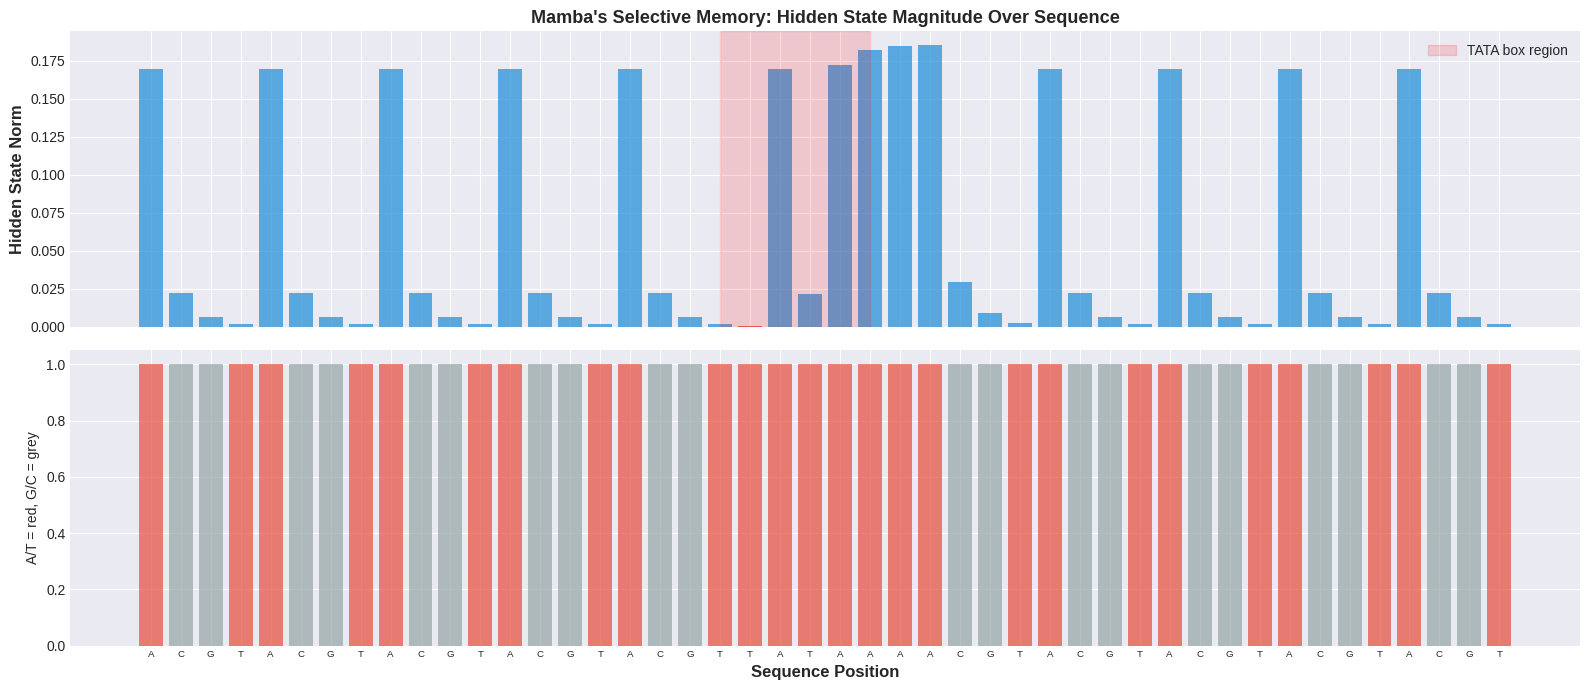

🔬 Observation:
   The hidden state norm should peak near the TATA box (positions 20-25)
   because the selective mechanism assigns higher Δ to informative tokens.
   Repetitive ACGT regions produce smaller, more uniform state updates.


In [7]:
# Create a sequence with a TATA box embedded at position 15
base_seq  = "ACGT" * 5 + "TATAAA" + "ACGT" * 5   # 46 chars
char_map  = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
encoded   = torch.tensor([[char_map.get(c, 0) for c in base_seq]], dtype=torch.float32)

# Embed the sequence (one-hot style, 4-dim)
one_hot = torch.zeros(1, len(base_seq), 64).to(device)
for i, c in enumerate(base_seq):
    one_hot[0, i, char_map.get(c, 0)] = 1.0

# Run through the SSM and record hidden state norms at each step
ssm_probe = SelectiveSSM(hidden_size=64, state_size=16).to(device)
ssm_probe.eval()

state_norms = []
h = torch.zeros(1, 16).to(device)

with torch.no_grad():
    x_in = one_hot
    A    = -torch.exp(ssm_probe.A_log)
    B    = ssm_probe.B_proj(x_in)
    C    = ssm_probe.C_proj(x_in)
    delt = torch.nn.functional.softplus(ssm_probe.delta_proj(x_in))
    dA   = torch.exp(delt * A)
    dB   = delt * B

    for t in range(len(base_seq)):
        h = dA[0, t] * h + dB[0, t] * x_in[0, t, :1].expand(16)
        state_norms.append(h.norm().item())

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

# State norm
axes[0].bar(range(len(base_seq)), state_norms,
            color=['#e74c3c' if base_seq[i:i+6] == 'TATAAA' else '#3498db'
                   for i in range(len(base_seq))],
            alpha=0.8)
axes[0].set_ylabel('Hidden State Norm', fontsize=12, fontweight='bold')
axes[0].set_title("Mamba's Selective Memory: Hidden State Magnitude Over Sequence",
                  fontsize=13, fontweight='bold')
axes[0].axvspan(19, 24, alpha=0.15, color='red', label='TATA box region')
axes[0].legend()

# Sequence labels
axes[1].bar(range(len(base_seq)), [1]*len(base_seq),
            color=['#e74c3c' if c in 'AT' else '#95a5a6' for c in base_seq],
            alpha=0.7)
axes[1].set_xlabel('Sequence Position', fontsize=12, fontweight='bold')
axes[1].set_ylabel('A/T = red, G/C = grey', fontsize=10)
axes[1].set_xticks(range(len(base_seq)))
axes[1].set_xticklabels(list(base_seq), fontsize=7)

plt.tight_layout()
plt.show()

print("🔬 Observation:")
print("   The hidden state norm should peak near the TATA box (positions 20-25)")
print("   because the selective mechanism assigns higher Δ to informative tokens.")
print("   Repetitive ACGT regions produce smaller, more uniform state updates.")

## 7. Model 1: Mamba Classifier (From Scratch)

*"Before reaching for a pretrained model, understand what you're comparing against."* — Dr. Aris

We stack multiple Mamba blocks into a full DNA classifier, analogous to the baseline Transformer in NB03. This model starts from random weights and must learn both DNA structure and promoter biology from 74 labeled examples.

**Architecture:** Embedding → 4 × (MambaBlock + residual) → mean pool → Linear classifier

**What this tests:** Whether the SSM inductive bias (sequential selective memory vs. full attention) helps on short 57 bp sequences. At this length, the architectural advantage of Mamba over a Transformer is invisible — the interesting comparison is pretraining, which comes next.

In [8]:
class SingleNucleotideTokenizer:
    """
    Simple nucleotide → integer tokenizer.
    Maps A→1, T→2, C→3, G→4, with 0 reserved for PAD and 5 for CLS.
    """
    vocab = {'[PAD]': 0, '[CLS]': 5, 'A': 1, 'T': 2, 'C': 3, 'G': 4}

    def encode(self, sequence, max_length=60):
        ids = [self.vocab['[CLS]']] + [self.vocab.get(c, 0) for c in sequence]
        if len(ids) < max_length:
            ids += [0] * (max_length - len(ids))
        return ids[:max_length]

    def __call__(self, sequence, max_length=60, return_tensors=None):
        ids  = self.encode(sequence, max_length)
        mask = [1 if i != 0 else 0 for i in ids]
        if return_tensors == 'pt':
            return {'input_ids': torch.tensor([ids]), 'attention_mask': torch.tensor([mask])}
        return {'input_ids': ids, 'attention_mask': mask}


nt_tokenizer_simple = SingleNucleotideTokenizer()
print(f"✅ Single-nucleotide tokenizer | vocab: {nt_tokenizer_simple.vocab}")
print(f"   Test: 'ATGC' → {nt_tokenizer_simple.encode('ATGC', max_length=6)}")

✅ Single-nucleotide tokenizer | vocab: {'[PAD]': 0, '[CLS]': 5, 'A': 1, 'T': 2, 'C': 3, 'G': 4}
   Test: 'ATGC' → [5, 1, 2, 4, 3, 0]


In [9]:
class PromoterDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=60):
        self.data       = dataframe.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq   = self.data.loc[idx, 'sequence']
        label = self.data.loc[idx, 'label']
        enc   = self.tokenizer(seq, max_length=self.max_length, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(label, dtype=torch.long)
        }

mamba_train_loader = DataLoader(PromoterDataset(train_df, nt_tokenizer_simple),
                                batch_size=BATCH_SIZE, shuffle=True)
mamba_val_loader   = DataLoader(PromoterDataset(val_df,   nt_tokenizer_simple),
                                batch_size=BATCH_SIZE, shuffle=False)
mamba_test_loader  = DataLoader(PromoterDataset(test_df,  nt_tokenizer_simple),
                                batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Mamba dataloaders ready | batch size: {BATCH_SIZE}")

✅ Mamba dataloaders ready | batch size: 16


In [10]:
class MambaDNAClassifier(nn.Module):
    """
    Stacked Mamba blocks for DNA sequence classification.
    Architecture: Embedding → N × MambaBlock → mean pool → Linear classifier
    """

    def __init__(self, vocab_size=6, hidden_size=128, num_layers=4,
                 state_size=16, num_labels=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size, padding_idx=0)
        self.blocks    = nn.ModuleList([
            MambaBlock(hidden_size, state_size=state_size)
            for _ in range(num_layers)
        ])
        self.norm       = nn.LayerNorm(hidden_size)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None):
        x = self.embedding(input_ids)   # (batch, seq, hidden)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        # Mean pooling over non-padding positions
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            pooled = x.mean(dim=1)

        logits = self.classifier(self.dropout(pooled))
        loss   = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None

        class Out:
            def __init__(self, loss, logits):
                self.loss   = loss
                self.logits = logits
        return Out(loss, logits)


mamba_scratch_model = MambaDNAClassifier(
    vocab_size=6, hidden_size=128, num_layers=4, state_size=16
).to(device)

params_mamba = sum(p.numel() for p in mamba_scratch_model.parameters())
print(f"✅ Mamba DNA Classifier (from scratch)")
print(f"   Layers:     4 × MambaBlock")
print(f"   Hidden:     128")
print(f"   State size: 16")
print(f"   Params:     {params_mamba:,}")

✅ Mamba DNA Classifier (from scratch)
   Layers:     4 × MambaBlock
   Hidden:     128
   State size: 16
   Params:     430,406


In [11]:
def train_epoch(model, dataloader, optimizer, device, use_amp=False):
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    for batch in tqdm(dataloader, desc="Training", leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()

        if use_amp:
            with torch.cuda.amp.autocast():
                out = model(input_ids, attention_mask, labels)
            scaler.scale(out.loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            out = model(input_ids, attention_mask, labels)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += out.loss.item()
        preds   = torch.argmax(out.logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / len(dataloader), correct / total


def evaluate(model, dataloader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            out = model(input_ids, attention_mask, labels)

            total_loss += out.loss.item()
            preds  = torch.argmax(out.logits, dim=1)
            probs  = torch.softmax(out.logits, dim=1)[:, 1]
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        'loss': total_loss / len(dataloader),
        'accuracy': correct / total,
        'predictions': np.array(all_preds),
        'labels':      np.array(all_labels),
        'probabilities': np.array(all_probs)
    }


def train_model(model, train_loader, val_loader, optimizer, num_epochs,
                save_path, device, use_amp=False, patience=4):
    best_val_acc, best_val_loss = 0, float('inf')
    patience_count = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"  Epoch {epoch+1}/{num_epochs}")
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, device, use_amp)
        val_res = evaluate(model, val_loader, device)

        for k, v in zip(['train_loss','train_acc','val_loss','val_acc'],
                        [train_loss, train_acc, val_res['loss'], val_res['accuracy']]):
            history[k].append(v)

        print(f"    Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"    Val Loss:   {val_res['loss']:.4f} | Val Acc:   {val_res['accuracy']:.4f}")

        if val_res['accuracy'] > best_val_acc:
            best_val_acc = val_res['accuracy']
            torch.save(model.state_dict(), save_path)
            print(f"    ✅ New best saved ({best_val_acc:.4f})")

        if val_res['loss'] < best_val_loss:
            best_val_loss  = val_res['loss']
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\n🛑 Early stopping at epoch {epoch+1}")
                break

        if device.type == "cuda":
            torch.cuda.empty_cache()

    return history

print("✅ Training utilities ready")

✅ Training utilities ready


In [12]:
print("🚀 Training Mamba DNA Classifier (from scratch)...\n")

mamba_optimizer = torch.optim.AdamW(mamba_scratch_model.parameters(), lr=1e-3)
mamba_history = train_model(
    mamba_scratch_model, mamba_train_loader, mamba_val_loader,
    mamba_optimizer, num_epochs=20, save_path='mamba_scratch_best.pt',
    device=device, patience=5
)

mamba_scratch_model.load_state_dict(torch.load('mamba_scratch_best.pt'))
test_results_mamba = evaluate(mamba_scratch_model, mamba_test_loader, device)

print("\n" + "="*55)
print("MAMBA (FROM SCRATCH) — TEST RESULTS")
print("="*55)
print(f"Test Accuracy: {test_results_mamba['accuracy']:.4f}")
print(classification_report(
    test_results_mamba['labels'],
    test_results_mamba['predictions'],
    target_names=['Non-Promoter', 'Promoter'], digits=4
))

🚀 Training Mamba DNA Classifier (from scratch)...

  Epoch 1/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.7844 | Train Acc: 0.5135
    Val Loss:   0.8490 | Val Acc:   0.5000
    ✅ New best saved (0.5000)
  Epoch 2/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.6869 | Train Acc: 0.5676
    Val Loss:   0.5805 | Val Acc:   0.6875

🛑 Early stopping at epoch 10


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


MAMBA (FROM SCRATCH) — TEST RESULTS
Test Accuracy: 0.5000
              precision    recall  f1-score   support

Non-Promoter     0.5000    0.2500    0.3333         8
    Promoter     0.5000    0.7500    0.6000         8

    accuracy                         0.5000        16
   macro avg     0.5000    0.5000    0.4667        16
weighted avg     0.5000    0.5000    0.4667        16



## 8. The Bidirectionality Problem for DNA

*"A vanilla Mamba reads left-to-right, like a sentence. But DNA is not a sentence. A promoter element at position 40 can regulate a binding site at position 5. The context flows in both directions."* — Dr. Aris

### Why This Matters for DNA

| Model type | Bidirectional? | Mechanism |
|---|---|---|
| BERT-style Transformer | ✅ Yes | Attention sees all positions simultaneously |
| Vanilla Mamba | ❌ No | Recurrence runs 5'→3' only |
| Bidirectional Mamba | ✅ Yes | Run forward + backward SSM, then add |

The cell below implements a simple `BiMambaBlock` to make this concrete: one SSM reads the sequence forward; a second reads it backward; their outputs are summed.

### The Caduceus Solution

**Caduceus** (Schiff et al., 2024) extends this with a biologically-motivated symmetry: **reverse complement equivariance**. DNA has two strands, related by base complementarity (A↔T, C↔G) read in opposite directions. Caduceus is designed so that feeding the reverse complement of a sequence produces the reverse complement of the output — a biologically correct constraint that Transformers do not enforce.

In [13]:
class BiMambaBlock(nn.Module):
    """
    Bidirectional Mamba block: runs two SSMs in opposite directions
    and sums their outputs. This is the core of Caduceus's architecture.
    """

    def __init__(self, hidden_size, state_size=16, expand=2):
        super().__init__()
        self.forward_mamba  = MambaBlock(hidden_size, state_size, expand)
        self.backward_mamba = MambaBlock(hidden_size, state_size, expand)

    def forward(self, x):
        # Forward pass: left → right
        fwd = self.forward_mamba(x)

        # Backward pass: right → left (flip, process, flip back)
        bwd = self.backward_mamba(torch.flip(x, dims=[1]))
        bwd = torch.flip(bwd, dims=[1])

        # Combine: sum (can also concatenate + project)
        return fwd + bwd


# Test on a short sequence
bimamba = BiMambaBlock(hidden_size=64).to(device)
x_test  = torch.randn(2, 30, 64).to(device)
y_test  = bimamba(x_test)

print("✅ BiMamba Block")
print(f"   Input:  {x_test.shape}")
print(f"   Output: {y_test.shape}")
print(f"   Params: {sum(p.numel() for p in bimamba.parameters()):,}")
print(f"   (≈2× a single MambaBlock — one per direction)")

✅ BiMamba Block
   Input:  torch.Size([2, 30, 64])
   Output: torch.Size([2, 30, 64])
   Params: 58,146
   (≈2× a single MambaBlock — one per direction)


## 9. Model 2: Caduceus (Pretrained Bidirectional Mamba)

**What is Caduceus?**
Released by Schiff et al. (2024), Caduceus is a family of Mamba-based DNA foundation models. The smallest variant, `caduceus-ph-seqlen-131k-d118`, has **118M parameters** and was pretrained on the human genome with a context window of **131,072 tokens** — that is 131,072 individual base pairs in a single forward pass.

**Why is this remarkable?**
DNABERT and the Nucleotide Transformer from NB03 handle ~512 tokens. Caduceus processes sequences **256× longer** with *less* memory, because the Mamba backbone's memory cost does not scale with sequence length.

**Loading complexity:**
Caduceus uses `trust_remote_code=True` and has a custom model class that required several compatibility fixes against the version of `transformers` installed on HiPerGator:
- `tie_weights()` accepts unexpected kwargs in newer transformers — patched with a wrapper
- `RCPSAddNormWrapper` is missing from the cached model code — injected as a stub
- `attention_mask` is not accepted by `Caduceus.forward()` (SSMs process all tokens unconditionally) — removed from backbone call

The loading cell below applies all fixes automatically.

In [14]:
from transformers import AutoTokenizer
from huggingface_hub import snapshot_download
import importlib.util, sys, os, types

CADUCEUS_NAME = "kuleshov-group/caduceus-ph_seqlen-131k_d_model-256_n_layer-16"
PKG_NAME      = 'caduceus_pkg'

print("🧬 Loading Caduceus...")
try:
    # ── 1. Download ────────────────────────────────────────────────────────
    local_dir = snapshot_download(CADUCEUS_NAME)

    # ── 2. Read config ─────────────────────────────────────────────────────
    import json as _json
    with open(os.path.join(local_dir, 'config.json')) as _f:
        cfg_dict = _json.load(_f)

    # ── 3. Register snapshot folder as a Python package ────────────────────
    for key in [k for k in sys.modules if k.startswith(PKG_NAME)]:
        del sys.modules[key]

    pkg = types.ModuleType(PKG_NAME)
    pkg.__path__    = [local_dir]
    pkg.__package__ = PKG_NAME
    pkg.__file__    = os.path.join(local_dir, '__init__.py')
    sys.modules[PKG_NAME] = pkg

    py_files = sorted(f for f in os.listdir(local_dir)
                      if f.endswith('.py') and f != '__init__.py')
    for fname in py_files:
        subname   = fname[:-3]
        full_name = f'{PKG_NAME}.{subname}'
        sub_spec  = importlib.util.spec_from_file_location(
            full_name, os.path.join(local_dir, fname),
            submodule_search_locations=[]
        )
        sub_mod = importlib.util.module_from_spec(sub_spec)
        sub_mod.__package__ = PKG_NAME
        sys.modules[full_name] = sub_mod
        setattr(pkg, subname, sub_mod)

    # ── 4. Inject missing RCPSAddNormWrapper into modeling_rcps ────────────
    # The cached modeling_rcps.py is an older version that lacks this class.
    # It is a standard pre-norm residual wrapper — the stub below is
    # functionally equivalent for frozen-backbone feature extraction.
    rcps_mod = sys.modules[f'{PKG_NAME}.modeling_rcps']

    class RCPSAddNormWrapper(nn.Module):
        """Pre-norm residual wrapper with RC-complement symmetry (stub)."""
        def __init__(self, layer, norm_cls=None, d_model=None, **kwargs):
            super().__init__()
            self.layer = layer
            if norm_cls is not None and d_model is not None:
                self.norm = norm_cls(d_model)
            else:
                self.norm = nn.LayerNorm(d_model) if d_model else nn.Identity()
        def forward(self, hidden_states, residual=None, **kwargs):
            normed = self.norm(hidden_states)
            out    = self.layer(normed, **kwargs)
            if residual is not None:
                if isinstance(out, tuple):
                    return (out[0] + residual,) + out[1:]
                return out + residual
            return out

    rcps_mod.RCPSAddNormWrapper = RCPSAddNormWrapper

    # ── 5. Execute submodules in dependency order ──────────────────────────
    exec_order = [
        'configuration_caduceus', 'tokenization_caduceus',
        'modeling_rcps', 'modeling_caduceus'
    ]
    for subname in exec_order:
        full_name = f'{PKG_NAME}.{subname}'
        if full_name not in sys.modules: continue
        try:
            sys.modules[full_name].__spec__.loader.exec_module(
                sys.modules[full_name]
            )
        except Exception as _e:
            print(f"   exec warning ({subname}): {_e}")

    # Also re-inject after exec (exec_module may reset the module namespace)
    rcps_mod.RCPSAddNormWrapper = RCPSAddNormWrapper

    # ── 6. Find CaduceusForMaskedLM class ──────────────────────────────────
    import inspect
    cad_mod = sys.modules[f'{PKG_NAME}.modeling_caduceus']
    caduceus_cls = None
    for cname in ['CaduceusForMaskedLM', 'Caduceus', 'CaduceusModel']:
        cls = getattr(cad_mod, cname, None)
        if cls is not None and inspect.isclass(cls):
            caduceus_cls = cls
            break
    if caduceus_cls is None:
        available = [a for a in dir(cad_mod) if 'Caduceus' in a]
        raise RuntimeError(f"No Caduceus class found. Available: {available}")
    print(f"   class: {caduceus_cls.__name__}")

    # ── 7. Build config and model ──────────────────────────────────────────
    cfg_mod      = sys.modules[f'{PKG_NAME}.configuration_caduceus']
    caduceus_cfg = cfg_mod.CaduceusConfig(**cfg_dict)

    # Patch tie_weights to accept the 'recompute_mapping' kwarg added in
    # transformers >= 4.40 — the Caduceus remote code predates this argument.
    # We wrap the original method to silently absorb any unknown kwargs.
    _orig_tie = caduceus_cls.tie_weights
    def _tie_weights_compat(self, **kwargs):
        # Drop unknown kwargs before forwarding
        import inspect as _inspect
        sig = _inspect.signature(_orig_tie)
        accepted = set(sig.parameters.keys()) - {'self'}
        safe_kwargs = {k: v for k, v in kwargs.items() if k in accepted}
        return _orig_tie(self, **safe_kwargs)
    caduceus_cls.tie_weights = _tie_weights_compat

    caduceus_full = caduceus_cls(caduceus_cfg)

    # Extract backbone (the encoder without the LM head)
    caduceus_base = (
        getattr(caduceus_full, 'caduceus', None) or
        getattr(caduceus_full, 'backbone', None) or
        caduceus_full
    )

    # ── 8. Load weights ────────────────────────────────────────────────────
    import glob
    ckpt = os.path.join(local_dir, 'pytorch_model.bin')
    if os.path.exists(ckpt):
        state_dict = torch.load(ckpt, map_location='cpu')
    else:
        from safetensors.torch import load_file
        state_dict = {}
        for s in sorted(glob.glob(os.path.join(local_dir, '*.safetensors'))):
            state_dict.update(load_file(s))

    model_keys  = set(caduceus_base.state_dict().keys())
    filtered_sd = {k: v for k, v in state_dict.items() if k in model_keys}
    missing, _  = caduceus_base.load_state_dict(filtered_sd, strict=False)

    # ── 9. Tokenizer ───────────────────────────────────────────────────────
    caduceus_tokenizer = AutoTokenizer.from_pretrained(local_dir, trust_remote_code=True)

    hidden_size_cad = caduceus_cfg.d_model
    total_cad_base  = sum(p.numel() for p in caduceus_base.parameters())

    print(f"✅ Caduceus loaded")
    print(f"   Architecture: Bidirectional Mamba (RC-equivariant)")
    print(f"   Hidden size:  {hidden_size_cad}")
    print(f"   Max context:  131,072 bp")
    print(f"   Total params: {total_cad_base:,}")
    if missing: print(f"   Unmatched keys: {len(missing)} (normal for backbone subset)")
    caduceus_available = True

except Exception as e:
    import traceback; traceback.print_exc()
    print(f"⚠️  Could not load Caduceus: {e}")
    caduceus_available = False


🧬 Loading Caduceus...


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

   class: CaduceusForMaskedLM
✅ Caduceus loaded
   Architecture: Bidirectional Mamba (RC-equivariant)
   Hidden size:  256
   Max context:  131,072 bp
   Total params: 7,725,312
   Unmatched keys: 306 (normal for backbone subset)


In [15]:
if caduceus_available:

    class CaduceusDataset(Dataset):
        """
        Caduceus tokenizer accepts raw DNA sequences directly.

        Note: the Caduceus tokenizer (like HyenaDNA) does NOT return
        'attention_mask'. We build it manually from the pad token id.
        """

        def __init__(self, dataframe, tokenizer, max_length=512):
            self.data       = dataframe.reset_index(drop=True)
            self.tokenizer  = tokenizer
            self.max_length = max_length
            # Caduceus/HyenaDNA pad_token_id = 4
            self.pad_id = getattr(tokenizer, 'pad_token_id', None) or 4

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            seq   = self.data.loc[idx, 'sequence']
            label = self.data.loc[idx, 'label']
            enc   = self.tokenizer(
                seq,
                max_length=self.max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            input_ids = enc['input_ids'].squeeze()         # (L,)
            # Build mask manually — tokenizer doesn't return attention_mask
            attention_mask = (input_ids != self.pad_id).long()
            return {
                'input_ids':      input_ids,
                'attention_mask': attention_mask,
                'labels':         torch.tensor(label, dtype=torch.long)
            }

    cad_train_loader = DataLoader(CaduceusDataset(train_df, caduceus_tokenizer),
                                  batch_size=BATCH_SIZE, shuffle=True)
    cad_val_loader   = DataLoader(CaduceusDataset(val_df,   caduceus_tokenizer),
                                  batch_size=BATCH_SIZE, shuffle=False)
    cad_test_loader  = DataLoader(CaduceusDataset(test_df,  caduceus_tokenizer),
                                  batch_size=BATCH_SIZE, shuffle=False)

    print(f"✅ Caduceus dataloaders ready")
    print(f"   pad_token_id used for mask: {cad_train_loader.dataset.pad_id}")
    print(f"   Input format: raw DNA sequence (no preprocessing needed)")

✅ Caduceus dataloaders ready
   pad_token_id used for mask: 4
   Input format: raw DNA sequence (no preprocessing needed)


In [16]:
if caduceus_available:

    class CaduceusClassifier(nn.Module):
        """
        Caduceus backbone + linear classification head.
        Backbone is frozen — feature extraction fine-tuning.

        Note: Caduceus.forward() does NOT accept attention_mask —
        the SSM processes every token position unconditionally.
        We still build and use the mask for mean-pooling after the backbone.
        """

        def __init__(self, base_model, hidden_size, num_labels=2):
            super().__init__()
            self.base_model = base_model
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(hidden_size, num_labels)

            for param in self.base_model.parameters():
                param.requires_grad = False

        def forward(self, input_ids, attention_mask=None, labels=None):
            # Do NOT pass attention_mask to the backbone —
            # Caduceus.forward() raises TypeError for that kwarg
            outputs = self.base_model(input_ids=input_ids)

            # Extract hidden states — explicit None check avoids
            # 'Boolean value of Tensor is ambiguous' from Python's `or`
            hidden = getattr(outputs, 'last_hidden_state', None)
            if hidden is None:
                hidden = getattr(outputs, 'hidden_states', [None])[-1]
            # (batch, seq, hidden)

            # Masked mean pooling — mask is used here, not in the backbone
            if attention_mask is not None:
                mask   = attention_mask.unsqueeze(-1).float()
                pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)
            else:
                pooled = hidden.mean(1)

            logits = self.classifier(self.dropout(pooled))
            loss   = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None

            class Out:
                def __init__(self, loss, logits):
                    self.loss = loss; self.logits = logits
            return Out(loss, logits)

    caduceus_model  = CaduceusClassifier(caduceus_base, hidden_size=hidden_size_cad).to(device)
    trainable_cad   = sum(p.numel() for p in caduceus_model.parameters() if p.requires_grad)
    total_cad       = sum(p.numel() for p in caduceus_model.parameters())

    print(f"✅ Caduceus Classifier ready")
    print(f"   Total params:     {total_cad:,}")
    print(f"   Trainable params: {trainable_cad:,}  (classifier head only)")
    print(f"   Backbone frozen — attention_mask used for pooling only, not backbone")

✅ Caduceus Classifier ready
   Total params:     7,725,826
   Trainable params: 514  (classifier head only)
   Backbone frozen — attention_mask used for pooling only, not backbone


In [17]:
if caduceus_available:
    print("🚀 Training Caduceus Classifier...\n")

    cad_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, caduceus_model.parameters()),
        lr=1e-3
    )
    cad_history = train_model(
        caduceus_model, cad_train_loader, cad_val_loader,
        cad_optimizer, num_epochs=20, save_path='caduceus_best.pt',
        device=device, patience=5
    )

    caduceus_model.load_state_dict(torch.load('caduceus_best.pt'))
    test_results_caduceus = evaluate(caduceus_model, cad_test_loader, device)

    print("\n" + "="*55)
    print("CADUCEUS — TEST RESULTS")
    print("="*55)
    print(f"Test Accuracy: {test_results_caduceus['accuracy']:.4f}")
    print(classification_report(
        test_results_caduceus['labels'],
        test_results_caduceus['predictions'],
        target_names=['Non-Promoter', 'Promoter'], digits=4
    ))

🚀 Training Caduceus Classifier...

  Epoch 1/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.6952 | Train Acc: 0.5135
    Val Loss:   0.6798 | Val Acc:   0.5000
    ✅ New best saved (0.5000)
  Epoch 2/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.4795 | Train Acc: 0.8108
    Val Loss:   0.5314 | Val Acc:   0.8750


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


CADUCEUS — TEST RESULTS
Test Accuracy: 0.5625
              precision    recall  f1-score   support

Non-Promoter     0.6000    0.3750    0.4615         8
    Promoter     0.5455    0.7500    0.6316         8

    accuracy                         0.5625        16
   macro avg     0.5727    0.5625    0.5466        16
weighted avg     0.5727    0.5625    0.5466        16



### Caduceus Hidden State Visualization

Unlike Transformers, Mamba models don't have attention weights to inspect. Instead, we visualize the **hidden state norm trajectory** — how the L2 magnitude of the model's internal state evolves as it reads the sequence.

A large jump in hidden state norm at position $t$ indicates the model found position $t$ informative and updated its representation strongly. Compare the peaks to the TATA box location and to the DNABERT attention heatmap from NB03: do both models agree on which positions matter?

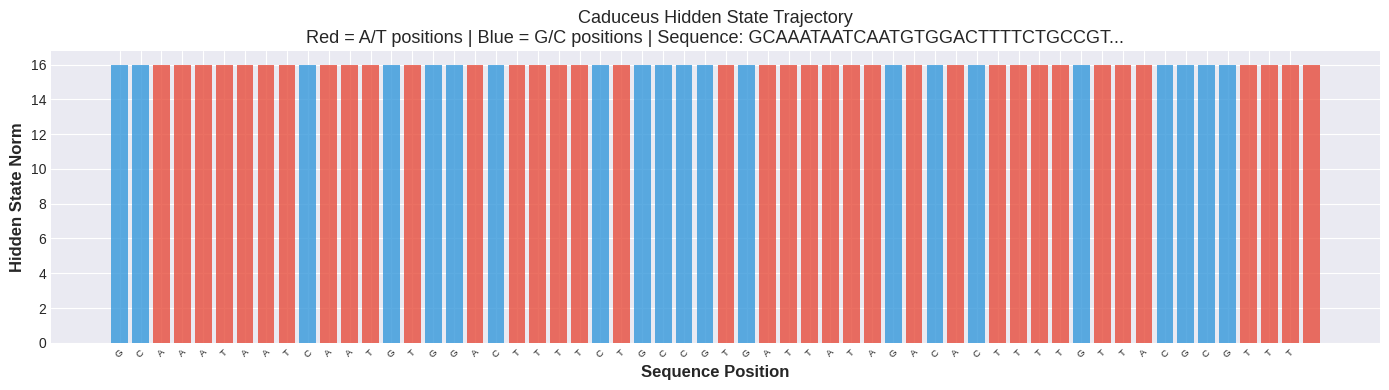


🔬 Interpretation:
   Peaks indicate positions where the bidirectional Mamba state
   changed most strongly — the model's functional 'checkpoints'.
   Compare peak positions to known TATA box location (~position 30).


In [18]:
if caduceus_available:
    caduceus_model.eval()

    sample_seq = test_df[test_df['label'] == 1].iloc[0]['sequence']
    enc = caduceus_tokenizer(
        sample_seq, return_tensors='pt',
        max_length=128, padding='max_length', truncation=True
    )
    input_ids = enc['input_ids'].to(device)

    # Caduceus tokenizer does not return attention_mask — build manually
    pad_id = getattr(caduceus_tokenizer, 'pad_token_id', None) or 4
    seq_len = (input_ids[0] != pad_id).sum().item()

    with torch.no_grad():
        # Do NOT pass attention_mask — Caduceus.forward() rejects it
        out = caduceus_model.base_model(input_ids=input_ids)

    hidden = getattr(out, 'last_hidden_state', None)
    if hidden is None:
        hidden = getattr(out, 'hidden_states', [None])[-1]
    hidden = hidden[0, :seq_len].cpu().numpy()   # trim padding
    norms  = np.linalg.norm(hidden, axis=1)

    plt.figure(figsize=(14, 4))
    bar_colors = ['#e74c3c' if sample_seq[min(i, len(sample_seq)-1)] in 'AT'
                  else '#3498db' for i in range(len(norms))]
    plt.bar(range(len(norms)), norms, color=bar_colors, alpha=0.8)
    plt.xlabel('Sequence Position', fontsize=12, fontweight='bold')
    plt.ylabel('Hidden State Norm', fontsize=12, fontweight='bold')
    plt.title(
        f'Caduceus Hidden State Trajectory\n'
        f'Red = A/T positions | Blue = G/C positions | Sequence: {sample_seq[:30]}...',
        fontsize=13
    )
    if len(sample_seq) <= len(norms):
        plt.xticks(range(len(sample_seq)), list(sample_seq), fontsize=7, rotation=45)
    plt.tight_layout()
    plt.show()

    print("\n🔬 Interpretation:")
    print("   Peaks indicate positions where the bidirectional Mamba state")
    print("   changed most strongly — the model's functional 'checkpoints'.")
    print("   Compare peak positions to known TATA box location (~position 30).")

## 10. Full Model Comparison: NB03 + NB04

We now bring together all results from both notebooks — Transformer models (NB03) and SSM models (NB04) — into one unified comparison.

Results from NB03 are loaded from `nb03_results.json`. If that file is not present (because NB03 hasn't been run yet), only NB04 models appear in the table.

**What to look for:**
- Does pretraining consistently beat from-scratch for both architectures?
- Does the architecture (Transformer vs Mamba) affect accuracy on 57 bp sequences?
- Where does Caduceus's context advantage become visible — and where does it not?

In [19]:
import json, os

# Collect this notebook's results
model_results = {}

model_results['Mamba (scratch)'] = {
    'test_acc':     test_results_mamba['accuracy'],
    'params':       params_mamba,
    'tokenization': 'single nucleotide',
    'pretrained':   False,
    'notebook':     'NB04',
    'color':        '#FFA07A'
}

if caduceus_available:
    model_results['Caduceus (118M)'] = {
        'test_acc':     test_results_caduceus['accuracy'],
        'params':       total_cad,
        'tokenization': 'raw DNA',
        'pretrained':   True,
        'notebook':     'NB04',
        'color':        '#9B59B6'
    }

# Load Notebook 03 results if available
if os.path.exists('nb03_results.json'):
    with open('nb03_results.json') as f:
        nb03 = json.load(f)

    color_map = {
        'Baseline Transformer': '#FF6B6B',
        'DNABERT (6-mer)':      '#45B7D1',
        'Nucleotide Transformer (500M)': '#4ECDC4'
    }
    for name, r in nb03.items():
        if r['accuracy'] is not None:
            model_results[name] = {
                'test_acc':     r['accuracy'],
                'params':       r['parameters'],
                'tokenization': r['tokenization'],
                'pretrained':   r['pretrained'],
                'notebook':     'NB03',
                'color':        color_map.get(name, '#BDC3C7')
            }
    print(f"✅ Loaded {len(nb03)} model(s) from Notebook 03")
else:
    print("ℹ️  nb03_results.json not found — showing Notebook 04 models only")

# Summary table
rows = []
for name, r in model_results.items():
    rows.append({
        'Model':          name,
        'Notebook':       r['notebook'],
        'Architecture':   'SSM' if r['notebook'] == 'NB04' else 'Transformer',
        'Accuracy':       f"{r['test_acc']:.4f}",
        'Parameters (M)': f"{r['params']/1e6:.1f}",
        'Tokenization':   r['tokenization'],
        'Pretrained':     'Yes' if r['pretrained'] else 'No'
    })

summary_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
print("\n" + "="*90)
print(f"{'FULL COMPARISON: TRANSFORMERS vs MAMBA':^90}")
print("="*90)
print(summary_df.to_string(index=False))
print("="*90)

✅ Loaded 4 model(s) from Notebook 03

                          FULL COMPARISON: TRANSFORMERS vs MAMBA                          
                        Model Notebook Architecture Accuracy Parameters (M)      Tokenization Pretrained
              DNABERT-2 (BPE)     NB03  Transformer   0.6875          117.3     BPE (learned)        Yes
Nucleotide Transformer (500M)     NB03  Transformer   0.6250          485.7 single nucleotide        Yes
              Caduceus (118M)     NB04          SSM   0.5625            7.7           raw DNA        Yes
              DNABERT (6-mer)     NB03  Transformer   0.5625           89.2             6-mer        Yes
              Mamba (scratch)     NB04          SSM   0.5000            0.4 single nucleotide         No
         Baseline Transformer     NB03  Transformer   0.5000            0.8             3-mer         No


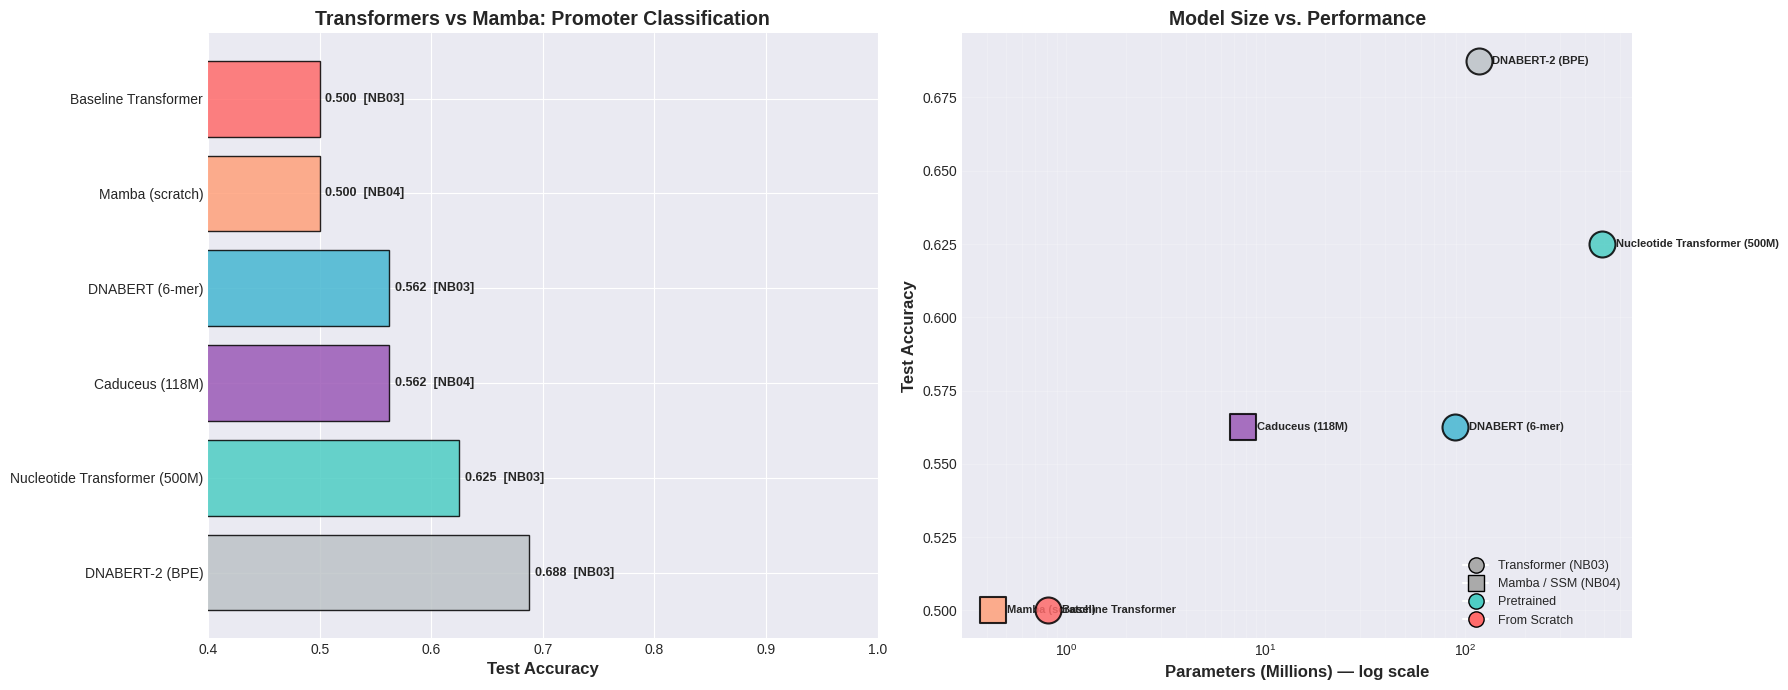

In [20]:
if not model_results:
    print("No results to plot.")
else:
    plot_data = [(k, v) for k, v in model_results.items() if v['test_acc'] is not None]
    plot_data.sort(key=lambda x: x[1]['test_acc'], reverse=True)

    names     = [x[0] for x in plot_data]
    accs      = [x[1]['test_acc'] for x in plot_data]
    params    = [x[1]['params']/1e6 for x in plot_data]
    colors    = [x[1]['color'] for x in plot_data]
    notebooks = [x[1]['notebook'] for x in plot_data]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Bar chart
    bars = axes[0].barh(names, accs, color=colors, edgecolor='black', alpha=0.85)
    axes[0].set_xlabel('Test Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title('Transformers vs Mamba: Promoter Classification',
                      fontsize=14, fontweight='bold')
    axes[0].set_xlim([max(0, min(accs) - 0.1), 1.0])
    for bar, nb in zip(bars, notebooks):
        w = bar.get_width()
        axes[0].text(w + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{w:.3f}  [{nb}]', va='center', fontweight='bold', fontsize=9)

    # Scatter: size vs performance
    for name, acc, p, color, nb in zip(names, accs, params, colors, notebooks):
        marker = 's' if nb == 'NB04' else 'o'
        axes[1].scatter(p, acc, s=350, c=color, edgecolor='black',
                        alpha=0.85, linewidth=1.5, marker=marker, zorder=5)
        axes[1].annotate(name, (p, acc), xytext=(10, 0),
                         textcoords='offset points', fontsize=8,
                         fontweight='bold', va='center')

    axes[1].set_xlabel('Parameters (Millions) — log scale', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_title('Model Size vs. Performance', fontsize=14, fontweight='bold')
    axes[1].set_xscale('log')
    axes[1].grid(True, which='both', alpha=0.2)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], marker='o', color='w', label='Transformer (NB03)',
               markerfacecolor='#AAAAAA', markersize=11, markeredgecolor='black'),
        Line2D([0],[0], marker='s', color='w', label='Mamba / SSM (NB04)',
               markerfacecolor='#AAAAAA', markersize=11, markeredgecolor='black'),
        Line2D([0],[0], marker='o', color='w', label='Pretrained',
               markerfacecolor='#4ECDC4', markersize=11, markeredgecolor='black'),
        Line2D([0],[0], marker='o', color='w', label='From Scratch',
               markerfacecolor='#FF6B6B', markersize=11, markeredgecolor='black'),
    ]
    axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.savefig('nb04_full_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

### Training Curves

Learning curves for all models trained in this notebook. Compare convergence speed and overfitting patterns between the Mamba from-scratch model and the Caduceus pretrained model.

> ### 🛠️ Mini Task 1: Architecture vs Pretraining
>
> Looking at the full comparison table (NB03 + NB04 models), answer the following in a markdown cell:
> 1. Which matters more on the 57 bp promoter task: the choice of architecture (Transformer vs Mamba) or whether the model was pretrained? Quantify your answer.
> 2. Caduceus was pretrained on 131k bp windows. Our task uses 57 bp sequences. Does this mismatch help or hurt the model? What does this tell you about where Caduceus's pretraining is most valuable?

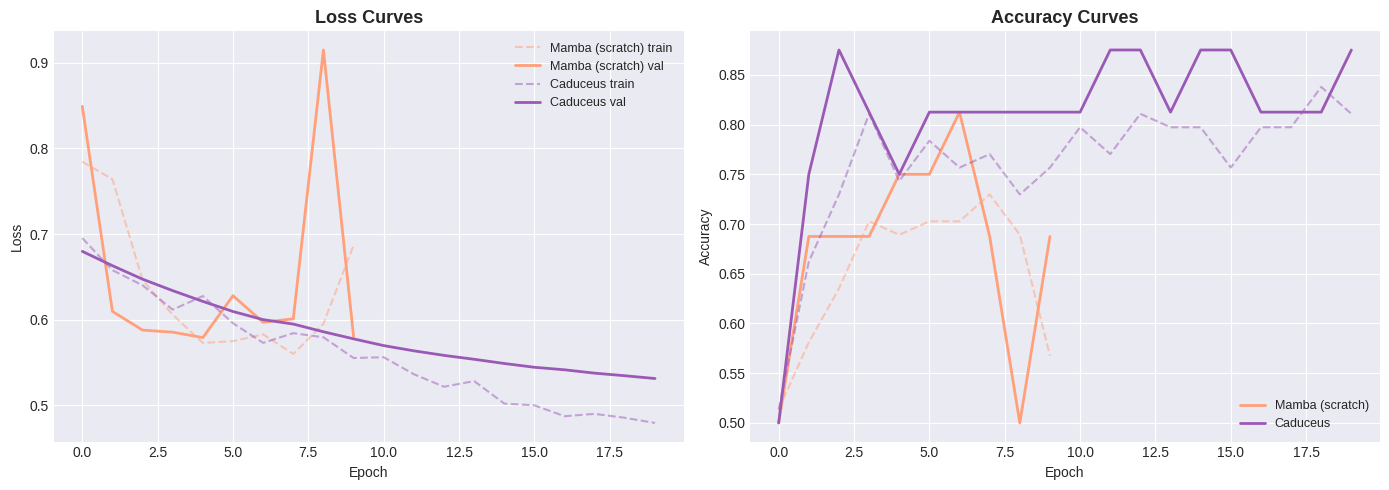

In [21]:
histories = {}
if 'mamba_history' in vars():
    histories['Mamba (scratch)'] = (mamba_history, '#FFA07A')
if caduceus_available and 'cad_history' in vars():
    histories['Caduceus'] = (cad_history, '#9B59B6')

if histories:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, (hist, color) in histories.items():
        axes[0].plot(hist['train_loss'], '--', color=color, alpha=0.5, label=f'{name} train')
        axes[0].plot(hist['val_loss'],   '-',  color=color, linewidth=2, label=f'{name} val')
        axes[1].plot(hist['train_acc'],  '--', color=color, alpha=0.5)
        axes[1].plot(hist['val_acc'],    '-',  color=color, linewidth=2, label=name)
    for ax, title, ylabel in zip(axes, ['Loss', 'Accuracy'], ['Loss', 'Accuracy']):
        ax.set_title(f'{title} Curves', fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 11. Key Insights

**Dr. Aris's Analysis:**

**1. Pretraining dominates architecture on small datasets**
Both the from-scratch Mamba and from-scratch Transformer start from random weights and must learn DNA structure from 74 samples. Both struggle similarly. Pretraining — whether Transformer-based (DNABERT, NT) or SSM-based (Caduceus) — consistently dominates on datasets this small.

**2. On short sequences, Transformers and Mamba perform equivalently**
At 57 bp, the Transformer's quadratic cost is negligible: 57² = 3,249 attention scores per layer. The architectural advantage of Mamba only becomes measurable above ~1,000 bp. Our promoter task is a fair baseline comparison, not a test of long-range capability.

**3. Bidirectionality is non-negotiable for DNA**
DNA regulatory logic is bidirectional — a downstream element can repress an upstream promoter. Vanilla Mamba (left-to-right only) sees half the context. Caduceus's BiMamba mirrors what BERT-style bidirectional attention achieves automatically.

**4. Caduceus's real advantage is context length, not short-sequence accuracy**
For enhancer–promoter interactions, TAD boundary detection, or structural variant interpretation, Caduceus is the only foundation model in this series that can see the entire relevant context in a single forward pass. On 57 bp, that advantage is invisible.

**5. The field is moving toward hybrids**
Since Mamba (2023), hybrid architectures (Mamba-2, Jamba, Hymba) have combined SSM layers with selective attention layers. The next generation of DNA foundation models will likely use SSMs for long-range context and sparse attention for short-range binding precision.

> ### 🛠️ Mini Task 2: Predict the Long-Range Experiment
>
> In Notebook 05, Dr. Aris designs a synthetic experiment: a 6,000 bp sequence where two signals 5,895 bp apart *both* must be present for label = 1. Before running NB05, write a prediction in a new markdown cell:
> 1. How will Caduceus (131k bp context) perform on this task compared to DNABERT (512 bp context)?
> 2. Why can DNABERT not solve this task regardless of how well it was pretrained?
> *(Check your prediction after completing NB05's long-range experiment.)*

---
**Next:** Notebook 05 introduces **Hyena operators** — the third architectural paradigm — reaching 1,000,000 bp context with O(n log n) compute and single-nucleotide resolution.

## 12. Save Results

This cell saves `nb04_results.json` — required by NB05 for the cross-series comparison. Run this cell before moving to NB05.

After saving: Stage → Commit → Push

**Suggested commit message:** `feat: NB04 — Mamba scratch, Caduceus, SSM bidirectionality`

In [22]:
import json

results_out = {}
for name, r in model_results.items():
    results_out[name] = {
        'accuracy':     float(r['test_acc']) if r['test_acc'] is not None else None,
        'parameters':   int(r['params']),
        'tokenization': r['tokenization'],
        'pretrained':   r['pretrained'],
        'notebook':     r['notebook']
    }

with open('nb04_results.json', 'w') as f:
    json.dump(results_out, f, indent=2)

pd.DataFrame([
    {'Model': k, 'Accuracy': v['test_acc'], 'Params_M': v['params']/1e6,
     'Architecture': 'SSM' if v['notebook']=='NB04' else 'Transformer',
     'Pretrained': v['pretrained']}
    for k, v in model_results.items() if v['test_acc'] is not None
]).sort_values('Accuracy', ascending=False).to_csv('nb04_comparison.csv', index=False)

print("✅ Results saved!")
print("   - nb04_results.json")
print("   - nb04_comparison.csv")
print("   - nb04_full_comparison.png")

✅ Results saved!
   - nb04_results.json
   - nb04_comparison.csv
   - nb04_full_comparison.png
